# 16 — Group → resource-type composition (negative rules)

For each major group, what kind of resource do they lack access to?

1. Overall distribution of groups by number of **negative (LESS)** rules.
2. Per-group **% breakdown** across the 8 high-level `resource_type`
   categories (Bodily Autonomy, Legal Standing, Household Authority,
   Material Wealth, Education, Political Power, Honor, Religious
   Standing).
3. **Net balance** (`MORE − LESS`) per group × resource type.

`group_meta` is multi-label (up to 3 canonicals per rule, joined with
`;`). We explode on `;`, so a rule annotated *Men;Elders* contributes
one unit to **both** buckets — aggregations treat each canonical as a
separate axis of the rule.

**Source**: `data/processed_data/rules_final_dataset_130works_april_2026.tsv`
(gold-filtered).

*Follows `notebook_rule.md`.*

## 1. Setup — imports, style, constants

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

EXCLUDE_GROUPS = {
    'Soldiers', 'Artisans', 'Philosophers',
    'The multitude', 'Heirs', 'Priests',
}

# Materiality-ordered: Bodily Autonomy is most material. Household
# Authority is excluded because in the corpus it never appears as a
# primary resource_type (only secondary — i.e. the `split(';')[0]`
# extraction never yields it).
TYPE_ORDER = [
    'Religious Standing',  # least material
    'Honor',
    'Political Power',
    'Education',
    'Material Wealth',
    'Legal Standing',
    'Bodily Autonomy',     # most material
]

GROUP_ORDER = ['Citizens', 'Slaves', 'The wealthy',
               'The poor', 'Men', 'Women']

In [2]:
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.frameon': False,
})

# Stable palette: one colour per resource_type.
TYPE_COLORS = {
    'Bodily Autonomy':    '#c0392b',
    'Legal Standing':     '#8e44ad',
    'Material Wealth':    '#27ae60',
    'Education':          '#f39c12',
    'Political Power':    '#2c6e91',
    'Honor':              '#16a085',
    'Religious Standing': '#7f8c8d',
}

## 2. Load data

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')
df_raw[['rule', 'directionality', 'group_meta',
        'resource_type']].head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv


,rule,directionality,group_meta,resource_type
0,Greek exclusion from large-scale statecraft,LESS,Greeks,Political Power
1,City-state local self-government,MORE,Citizens;Greeks,Political Power
2,Noble access to magistracies,MORE,Nobles,Political Power
3,Citizen assembly voting,MORE,Citizens,Political Power
4,Proconsular annulment of local power,LESS,Citizens,Political Power


## 3. Preprocessing

Keep only rated rules (MORE / LESS) with a known `group_meta` and
`resource_type`. Compound `resource_type` values (e.g. *Material
Wealth; Legal Standing*) are collapsed to the **primary** (first-listed)
type so percentages sum to 100 %. `group_meta` is exploded on `;` so a
multi-label rule contributes to every meta-group it belongs to. Drop
the same small / noisy group buckets as the other notebooks.

In [4]:
n0 = len(df_raw)

df = df_raw[df_raw['directionality'].isin(['MORE', 'LESS'])
            & df_raw['group_meta'].notna()
            & df_raw['resource_type'].notna()].copy()
n1 = len(df)

df['resource_type_primary'] = df['resource_type'].map(
    lambda s: s.split(';')[0].strip())

# Multi-label group_meta: explode on ';' so a rule with "Men;Elders"
# contributes one unit to each of Men and Elders.
df = (df.assign(group_meta=df['group_meta']
                            .str.split(r'\s*;\s*'))
        .explode('group_meta'))
df['group_meta'] = df['group_meta'].str.strip()
df = df[df['group_meta'] != ''].copy()
n_exploded = len(df)

df = df[~df['group_meta'].isin(EXCLUDE_GROUPS)].copy()
n2 = len(df)

neg = df[df['directionality'] == 'LESS'].copy()

assert df['directionality'].isin(['MORE', 'LESS']).all()
assert df['resource_type_primary'].notna().all()

print(f'Raw rules:                             {n0:,}')
print(f'After MORE/LESS + group + type filter: {n1:,}  (dropped {n0-n1})')
print(f'After group_meta explode:              {n_exploded:,}  '
      f'(+{n_exploded-n1} rows from multi-label)')
print(f'After dropping small groups:           {n2:,}  (dropped {n_exploded-n2})')
print(f'\nNegative (LESS) row-group pairs: {len(neg):,} | '
      f'distinct groups: {neg["group_meta"].nunique()} | '
      f'resource types: {neg["resource_type_primary"].nunique()}')
df.head()

Raw rules:                             1,011
After MORE/LESS + group + type filter: 998  (dropped 13)
After group_meta explode:              1,124  (+126 rows from multi-label)
After dropping small groups:           1,007  (dropped 117)

Negative (LESS) row-group pairs: 456 | distinct groups: 26 | resource types: 7


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type,group_meta,resource_type_primary
0,tlg0007.tlg118.perseus-eng3::0,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Greek ethnicity is a birth-fixed biological/cu...,0,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...,Political Power,Greeks,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Citizens,Political Power
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Greeks,Political Power
2,tlg0007.tlg118.perseus-eng3::2,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,'Noble birth' is a strictly immutable lineage-...,0,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...,Political Power,Nobles,Political Power
3,tlg0007.tlg118.perseus-eng3::3,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,Status as 'Athenian citizens' and 'free men' i...,0,Refers to the current population of Athens rul...,4,"While hortatory, it identifies the group as 'f...",0,Being 'free' or 'Greek' does not automatically...,Political Power,Citizens,Political Power


## 4. Counts table — groups × resource_type (negative rules)

In [5]:
tbl = (neg[neg['group_meta'].isin(GROUP_ORDER)]
         .groupby(['group_meta', 'resource_type_primary']).size()
         .unstack(fill_value=0)
         .reindex(index=GROUP_ORDER, columns=TYPE_ORDER, fill_value=0))
tbl['Total'] = tbl.sum(axis=1)
tbl

resource_type_primary,Religious Standing,Honor,Political Power,Education,Material Wealth,Legal Standing,Bodily Autonomy,Total
group_meta,,,,,,,,
Citizens,5,5,25,0,22,13,25,95
Slaves,1,0,8,1,4,1,29,44
The wealthy,0,1,4,0,56,2,2,65
The poor,0,2,20,0,1,5,2,30
Men,1,0,6,0,1,2,7,17
Women,3,4,6,1,7,5,17,43


## 5. Figures

### Figure 1: Groups by number of negative rules

              negative_rules
group_meta                  
Citizens                  95
The wealthy               65
Foreigners                58
Slaves                    44
Women                     43
The poor                  30
Minors                    28
Magistrates               26
Men                       17
Nobles                    12
Greeks                     6
Other                      5
The educated               4
Kings                      3
Elders                     3
Spartans                   3
Exiles                     2
Sailors                    2
Wives                      2
Christians                 2
Sick                       1
Romans                     1
Syrians                    1
Poets                      1
Physicians                 1
Orphans                    1


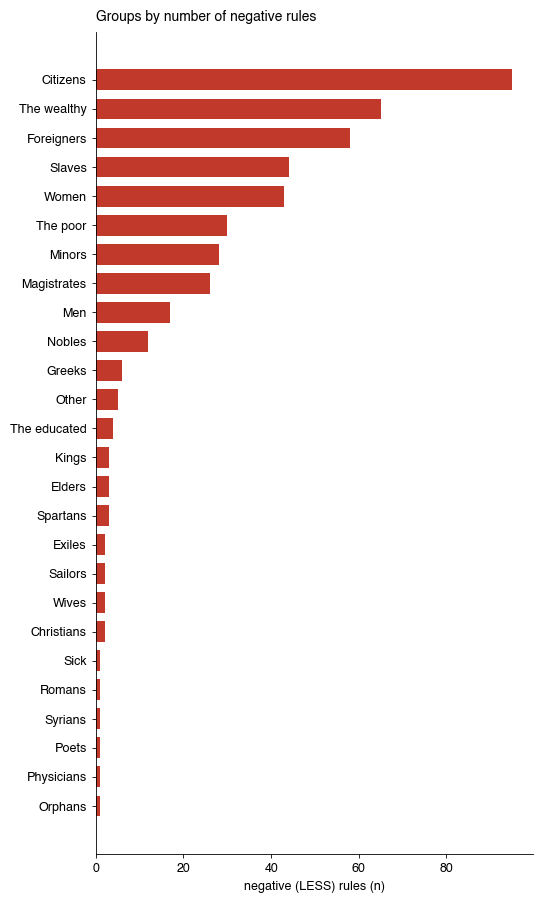

In [6]:
counts = neg['group_meta'].value_counts()

fig, ax = plt.subplots(figsize=(5.5, max(3.5, 0.35 * len(counts))))
y = np.arange(len(counts))
ax.barh(y, counts.values, color='#c0392b', edgecolor='none', height=0.72)
ax.set_yticks(y)
ax.set_yticklabels(counts.index)
ax.invert_yaxis()
ax.set_xlabel('negative (LESS) rules (n)')
ax.set_title('Groups by number of negative rules',
             loc='left', fontweight='bold', pad=8)
fig.tight_layout()
print(counts.to_frame('negative_rules'))

### Figure 2: Net balance (MORE − LESS) per group × resource type

Diverging bars: positive (blue, right) → group gets more positive than
negative rules for that resource type; negative (red, left) → the
opposite. Zero = parity or no rules of that type.

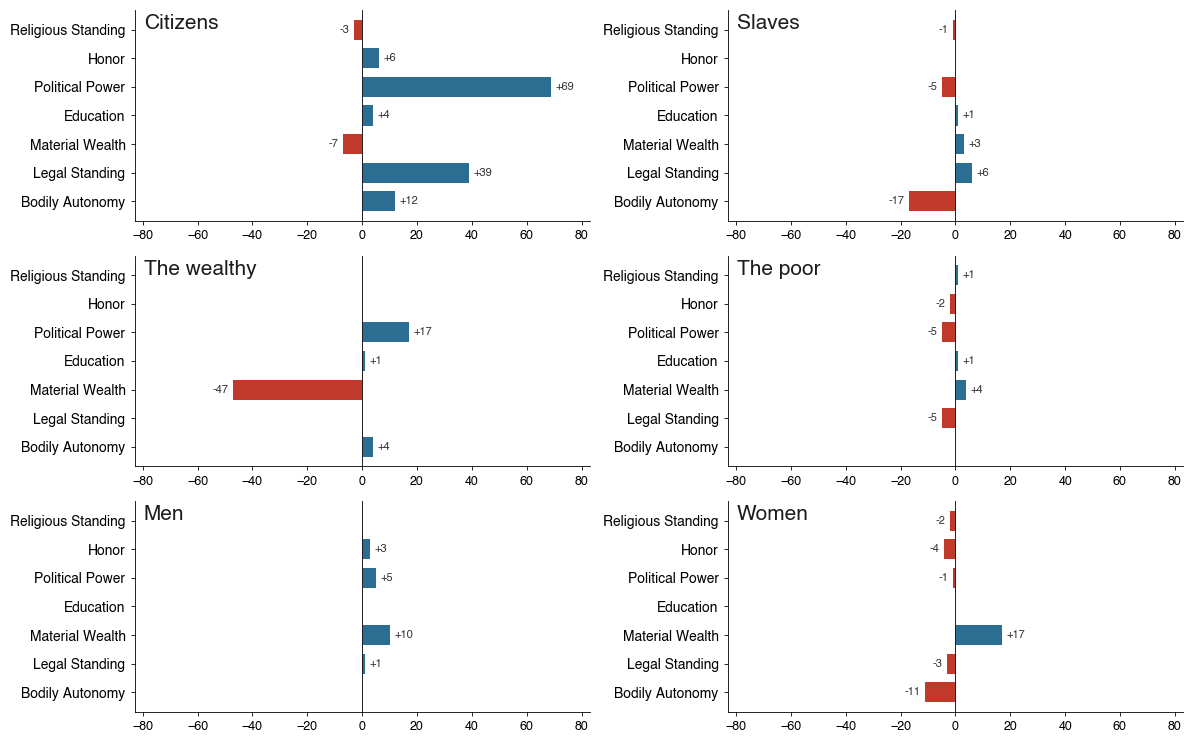

In [7]:
more_tbl = (df[df['directionality'] == 'MORE']
            .groupby(['group_meta', 'resource_type_primary']).size()
            .unstack(fill_value=0)
            .reindex(index=GROUP_ORDER, columns=TYPE_ORDER, fill_value=0))
less_tbl = (df[df['directionality'] == 'LESS']
            .groupby(['group_meta', 'resource_type_primary']).size()
            .unstack(fill_value=0)
            .reindex(index=GROUP_ORDER, columns=TYPE_ORDER, fill_value=0))
net = more_tbl - less_tbl

xmax = max(abs(net.values.min()), abs(net.values.max()))
xmax = int(xmax * 1.2) + 1

ncols_local = 2
n_groups = len(GROUP_ORDER)
nrows = int(np.ceil(n_groups / ncols_local))
fig, axes = plt.subplots(nrows, ncols_local,
                         figsize=(12, max(3.5, 2.5 * nrows)),
                         squeeze=False)

for k, g in enumerate(GROUP_ORDER):
    ax = axes[k // ncols_local][k % ncols_local]
    vals = net.loc[g, TYPE_ORDER].values
    y = np.arange(len(TYPE_ORDER))
    colors = ['#2c6e91' if v > 0 else ('#c0392b' if v < 0 else '#cccccc')
              for v in vals]
    ax.barh(y, vals, color=colors, edgecolor='none', height=0.7)
    ax.axvline(0, color='#1d1d1f', linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(TYPE_ORDER, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis='x', labelsize=9)
    ax.text(0.02, 0.98, g, transform=ax.transAxes,
            fontsize=15, fontweight='bold', color='#1d1d1f', va='top')
    for yi, v in zip(y, vals):
        if v != 0:
            offset = xmax * 0.02 if v > 0 else -xmax * 0.02
            ha = 'left' if v > 0 else 'right'
            ax.text(v + offset, yi, f'{int(v):+d}',
                    ha=ha, va='center', fontsize=8, color='#333')

for k in range(n_groups, nrows * ncols_local):
    axes[k // ncols_local][k % ncols_local].axis('off')

fig.tight_layout()

## 6. Robustness — triples shared by ≥ 2 authors

Repeat Figures 1–2 on a stricter subset: a row is kept only if the
triple *(directionality, resource_type_primary, group_meta)* it
contributes to is **shared by at least two distinct `perseus_author`
values** in the corpus. Patterns attested in only one writer's voice
drop out; consensus patterns remain.

In [8]:
triple_cols = ['directionality', 'resource_type_primary', 'group_meta']
n_authors_per_triple = (df.groupby(triple_cols)['perseus_author']
                          .nunique().rename('n_authors'))
shared_triples = n_authors_per_triple[n_authors_per_triple >= 2].index

df_shared = (df.set_index(triple_cols)
               .loc[shared_triples]
               .reset_index())
neg_shared = df_shared[df_shared['directionality'] == 'LESS'].copy()

print(f'Distinct triples total:             {len(n_authors_per_triple):,}')
print(f'Triples with ≥2 authors:            {len(shared_triples):,}')
print(f'Row-group pairs after filter:       {len(df_shared):,}  '
      f'(of {len(df):,})')
print(f'Negative pairs after filter:        {len(neg_shared):,}  '
      f'(of {len(df[df["directionality"]=="LESS"]):,})')

Distinct triples total:             183
Triples with ≥2 authors:            88
Row-group pairs after filter:       879  (of 1,007)
Negative pairs after filter:        388  (of 456)


### Figure 3: Groups by number of negative rules — shared ≥ 2 authors

             negative_rules
group_meta                 
Citizens                 95
The wealthy              62
Foreigners               56
Women                    42
Slaves                   41
Minors                   27
Magistrates              26
Men                      15
Nobles                   10
The poor                  7
Other                     4
Greeks                    3


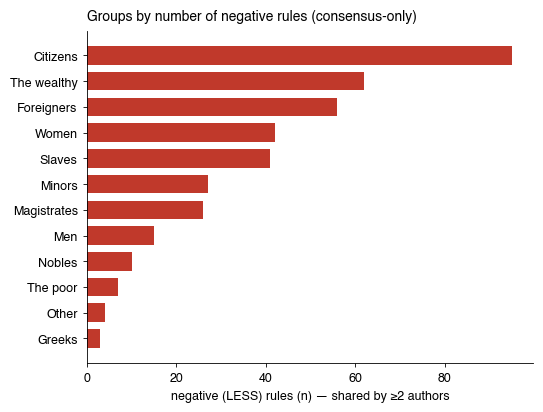

In [9]:
counts_shared = neg_shared['group_meta'].value_counts()

fig, ax = plt.subplots(figsize=(5.5, max(3.5, 0.35 * len(counts_shared))))
y = np.arange(len(counts_shared))
ax.barh(y, counts_shared.values, color='#c0392b',
        edgecolor='none', height=0.72)
ax.set_yticks(y)
ax.set_yticklabels(counts_shared.index)
ax.invert_yaxis()
ax.set_xlabel('negative (LESS) rules (n) — shared by ≥2 authors')
ax.set_title('Groups by number of negative rules (consensus-only)',
             loc='left', fontweight='bold', pad=8)
fig.tight_layout()
print(counts_shared.to_frame('negative_rules'))

### Figure 4: Net balance per group × resource type — shared ≥ 2 authors

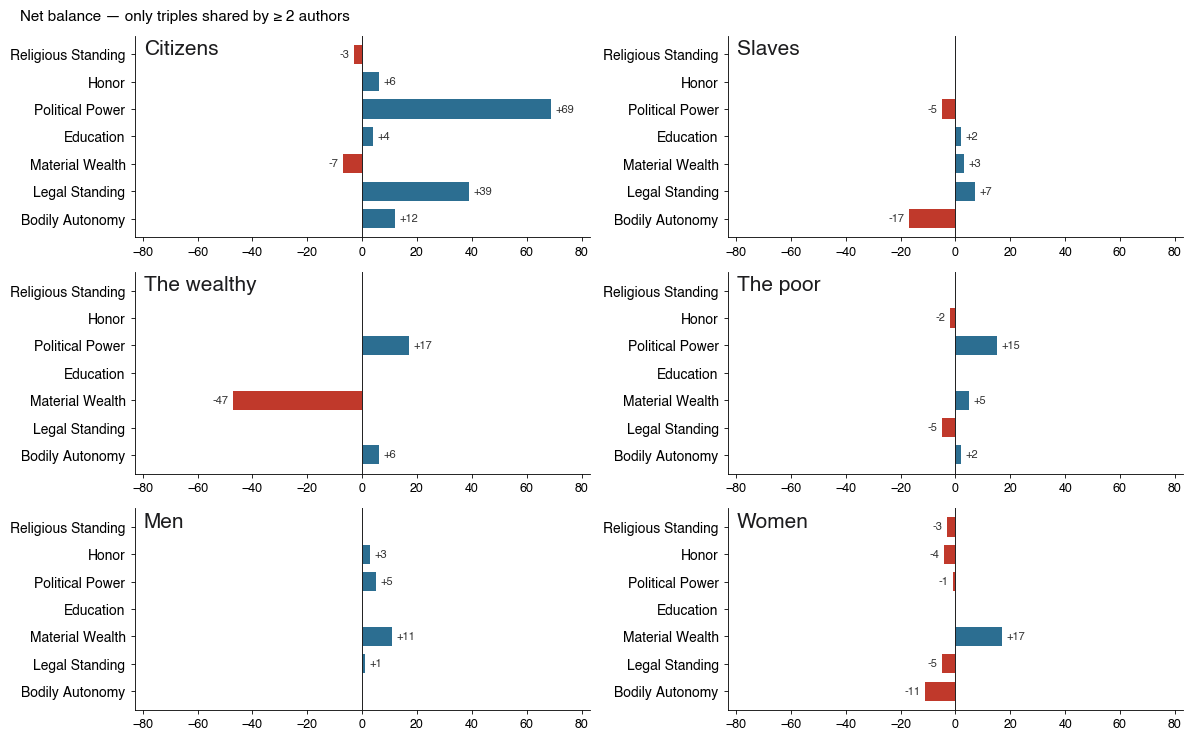

In [10]:
more_s = (df_shared[df_shared['directionality'] == 'MORE']
          .groupby(['group_meta', 'resource_type_primary']).size()
          .unstack(fill_value=0)
          .reindex(index=GROUP_ORDER, columns=TYPE_ORDER, fill_value=0))
less_s = (df_shared[df_shared['directionality'] == 'LESS']
          .groupby(['group_meta', 'resource_type_primary']).size()
          .unstack(fill_value=0)
          .reindex(index=GROUP_ORDER, columns=TYPE_ORDER, fill_value=0))
net_s = more_s - less_s

xmax = max(abs(net_s.values.min()), abs(net_s.values.max()))
xmax = int(xmax * 1.2) + 1

ncols_local = 2
n_groups = len(GROUP_ORDER)
nrows = int(np.ceil(n_groups / ncols_local))
fig, axes = plt.subplots(nrows, ncols_local,
                         figsize=(12, max(3.5, 2.5 * nrows)),
                         squeeze=False)

for k, g in enumerate(GROUP_ORDER):
    ax = axes[k // ncols_local][k % ncols_local]
    vals = net_s.loc[g, TYPE_ORDER].values
    y = np.arange(len(TYPE_ORDER))
    colors = ['#2c6e91' if v > 0 else ('#c0392b' if v < 0 else '#cccccc')
              for v in vals]
    ax.barh(y, vals, color=colors, edgecolor='none', height=0.7)
    ax.axvline(0, color='#1d1d1f', linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(TYPE_ORDER, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis='x', labelsize=9)
    ax.text(0.02, 0.98, g, transform=ax.transAxes,
            fontsize=15, fontweight='bold', color='#1d1d1f', va='top')
    for yi, v in zip(y, vals):
        if v != 0:
            offset = xmax * 0.02 if v > 0 else -xmax * 0.02
            ha = 'left' if v > 0 else 'right'
            ax.text(v + offset, yi, f'{int(v):+d}',
                    ha=ha, va='center', fontsize=8, color='#333')

for k in range(n_groups, nrows * ncols_local):
    axes[k // ncols_local][k % ncols_local].axis('off')

fig.suptitle('Net balance — only triples shared by ≥ 2 authors',
             x=0.02, ha='left', fontweight='bold', fontsize=11)
fig.tight_layout()